![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [1]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
#!pip install -r requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [3]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline

In [4]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [5]:
df.shape

(541462, 3)

<Axes: >

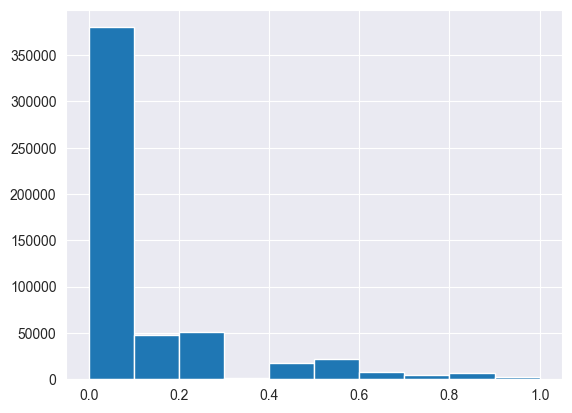

In [6]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [7]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [8]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [9]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [10]:
# Celda 1

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Definimos el CountVectorizer básico
vectorizer = CountVectorizer(max_features=10000)

# 2. Realizamos las transformaciones de texto a vectores utilizando CountVectorizer
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 3. Entrenamos el modelo de regresión lineal con los vectores CountVectorizer
model = LinearRegression()
model.fit(X_train_vec, y_train)

# 4. Predicción y Evaluación
y_pred = model.predict(X_test_vec)
mse_cvect = mean_squared_error(y_test, y_pred)

print("MSE:", mse_cvect)

MSE: 0.023426262752711948


### **Hallazgos punto 1**
Implementamos un modelo de regresión utilizando la técnica de tokenización basada en CountVectorizer, para transformr el texto en una representación numérica basada en la frecuencia de las palabras. El modelo obtuvo un error cuadrático medio (MSE) de 0.0234, lo que indica un buen desempeño teniendo en cuenta que la variable objetivo se encuentra en el rango de 0 a 1.De igual forma, este resultado sugiere que, a pesar de ser una técnica relativamente simple, la representación tipo “bag of words” permite capturar patrones relevantes en los comentarios para predecir su nivel de toxicidad.

Sin embargo, este enfoque no considera el orden de las palabras ni el contexto semántico, por lo que podríamos mejorar nuestro enfoque utilizando técnicas como n-gramas o representaciones basadas en embeddings. Además, pudimos observar que el dataset presenta un desbalance hacia valores bajos de toxicidad, lo cual puede influir en el desempeño del modelo.

## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 2
# 1. Definimos el CountVectorizer haciendo uso de trigramas
vectorizer_trigrama = CountVectorizer(max_features=10000, ngram_range=(3,3))

# 2. Realizamos las transformaciones de texto a vectores utilizando CountVectorizer con trigramas
X_train_vec_trigrama = vectorizer_trigrama.fit_transform(X_train)
X_test_vec_trigrama = vectorizer_trigrama.transform(X_test)

# 3. Entrenamos el modelo de regresión lineal con los vectores trigramas
model_trigrama = LinearRegression()
model_trigrama.fit(X_train_vec_trigrama, y_train)

# 4. Predicción y Evaluación
y_pred_trigrama = model_trigrama.predict(X_test_vec_trigrama)
mse_trigrama = mean_squared_error(y_test, y_pred_trigrama)

print("MSE:", mse_trigrama)

MSE: 0.037911757952476866


### **Hallazgos punto 2**

Siguiendo la consigna implementeamos el mismo modelo de regresión para nuestro vector con la diferencia de que en este caso estamos haciéndolo con n-gramas de exactamente tres elementos, al evaluar los resultados y compararlos con los obtenidos en el punto anterior encontramos que el MSE es peor, esto puede estar explicado porque restringir los n-gramas exactamente a tres elementos limita demasiado la capacidad de comprensión del modelo, pues ahora no busca una palabra para asociarla como tóxica sino busca exactamente la combinación de tres palabras para asignar un patrón.
Por ejemplo, es mucho más fácil determinar que la presencia de palabra "desagradable" en un comentario lo hace tóxico que buscar exactamente "un video desagradable".

## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

### **Hallazgos punto 3**

De acuerdo a nuestra investigación la función ``TFIDFVectorizer`` es un vector con pesos de palabra ponderados; es decir, si en ``CountVectorizer`` cada una de las palabras tiene el mismo peso, en ``TFIDF`` las palabras más frecuentes (``Term Frecuency``) en el vector tienen más peso relativo dentro del comentario y de la misma manera las palabras que son más frecuentes entre todos los vectores (``Inverse Document Frecuency``) tienen menos peso relativo (son penalizadas). 

1. ``TF - Term Frequency``: hace la medición de la frecuencia de un término o tóken dentro de un documento
$$TF(t,d) = \frac{\text{Número de veces que aparece el término } t \text{ en el documento } d}{\text{Total de términos en el documento } d}$$

2. ``IDF - Inverse document Frecuency``: realiza la medición de qué tan común o qué tan raro es el token dentro del documento
$$IDF(t) = \log\left(\frac{\text{Total de documentos}}{\text{Número de documentos que contienen el término } t}\right)$$

3. ``TFIDF``: La fórmula final para TFIDF es
$$TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)$$

La idea de esta función parte de que las palabras que son transversales a todos los vectores son menos relevantes para clasificarlos por ejemplo articulos (el, la, los, las) son palabras que aparecen mucho pero que contienen muy poca información, en cambio palabras no tan repetidas como adjetivos pueden ser más útiles para entender el sentido de un texto.

- Ventajas de ``TFIDF``:
    - Reduce el ruido de los datos dado que penaliza de forma automática aquellos tokens de alta frecuencia presentes en los documentos.
    - Los términos relevantes de los documentos son fácilmente identificados y asignados con pesos mayores dado su nivel de importancia.
    - Su escalabilidad es mucho mejor para documentación extensiva, contexto en el cual las palabras comunes de baja relevancia dominarían el conteo simple que realiza CountVectorizer.

- Desventajas de ``TFIDF``:
    - Es menos interpretable dado que la intuición es más compleja que un conteo simple (CountVectorizer).
    - Es muy sensible a términos que aparecen en un solo documento, es muy posible que esos términos únicos recuban un peso muy alto.
    - No conserva la información sobre el conteo de palabras, por lo que esta se pierde.
    - Tiene un costo computacional mucho mayor que `CountVectorizer`.

Podemos concluir que la función de ``TFIDFVectorizer`` es mucho mejor que la ``CountVectorizer`` en la medida que penaliza aquellos tokens de múltiple repetición y poca carga informativa; dando un mayor valor a los tokens clave , pensamos sin embargo que en textos con muchos reviews con la misma palabra, por ejemplo un video que todo el mundo coincide que es "bueno" vamos a estar perdiendo esta información y probablemente sobredimensionando outliers.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [12]:
# Celda 4
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Definimos el vectorizador TF-IDF para comparar con el CountVectorizer básico
vectorizer_tfidf = TfidfVectorizer(max_features=10000)

# 2. Realizamos las transformaciones de texto a vectores utilizando TF-IDF
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

# 3. Entrenamos el modelo de regresión lineal con los vectores TF-IDF
model_tfidf = LinearRegression()
model_tfidf.fit(X_train_tfidf, y_train)

# 4. Predicción y Evaluación
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)

print("MSE con TF-IDF:", mse_tfidf)


MSE con TF-IDF: 0.01906746265027497


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [13]:
# Celda 5

import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['CountVectorizer', 'Trigrama', 'TF-IDF'],
    'MSE': [mse_cvect, mse_trigrama, mse_tfidf]
})

resultados

,Modelo,MSE
0,CountVectorizer,0.023426
1,Trigrama,0.037912
2,TF-IDF,0.019067


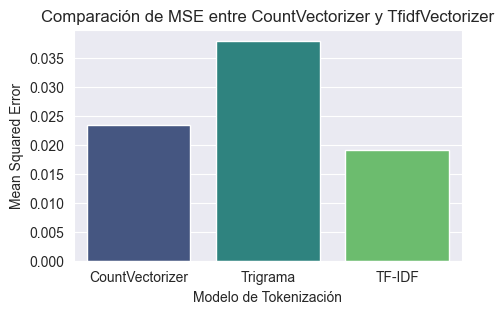

In [14]:
### Punto 5.1 - Comparación y análisis de resultados

figure, ax = plt.subplots(figsize=(5, 3))
ax = sns.barplot(x = 'Modelo', y = 'MSE', data = resultados, palette = 'viridis')
plt.title('Comparación de MSE entre CountVectorizer y TfidfVectorizer')
plt.ylabel('Mean Squared Error')
plt.xlabel('Modelo de Tokenización')
plt.show()

### Punto 5.1 - Comparación y análisis de resultados

Al comparar el desempeño de los tres modelos de vectorización, se observaron los siguientes resultados:

#### Clasificación de modelos por desempeño:

1. ``**TF-IDF**``: Este modelo obtuvo el MSE más bajo debido a su capacidad para identificar términos distintivos en cada comentario mediante la ponderación TF-IDF. Su ventaja principal radica en que penaliza automáticamente palabras comunes que aparecen frecuentemente en todos los documentos (como artículos, preposiciones y conectores), mientras resalta términos con mayor valor discriminativo. Esta normalización permite que el modelo capture mejor las características únicas de cada clase.

2. ``**CountVectorizer**``: A pesar de su simplicidad, este modelo demostró un desempeño destacable. Este resultado demuestra que la frecuencia absoluta de términos, sin necesidad de ponderaciones adicionales, ya contiene información valiosa.

3. ``**CountVectorizer con n-gramas**``: El desempeño limitado puede atribuirse a la rigidez del enfoque de ``n-gramas fijos (n=3)``, que requiere coincidencias exactas de secuencias de tres palabras consecutivas. Esta restricción reduce significativamente el número de patrones detectables, especialmente en textos con variabilidad léxica o sintáctica, generando una matriz de características menos generalizable.

#### Cuándo hacer uso de cada modelo?:

1. **countVectorizer**
- Usar con Datasets para los cuales la frecuencia simple de los tokens sí es informativa.
- Usarlo durante la etapa de Análisis exploratorio de Datos para entender las palabras más frecuentes.
- Para textos cortos
- Cuando se tienen capacidades computacionales limitadas, dado que es un modelo simple que trae ventajas para tareas simples como análisis de sentimientos básicos, detección de spam, etc.
- Si necesitamos que el modelo y sus resultados sean fácilmente interpretables.

2. **CountVectorizer con n-gramas**:
- El orden y contexto de las palabras es lo que importa (documentos con alta ambigüedad léxica)
- Documentos con lenguaje técnico especializado y patrones de muchas palabras que solas no tendrían significado pero juntas tienen sentido (ej: cliente reclama, inteligencia artificial).

3. **TF-IDF**
- Clasificación para documentos largos con contenido especializado como artículos, papers de investigación o informes.
- Datasets grandes y con mucha diversidad en la información.
- Clustering de documentos por temática o similitud.
- Cuando queremos identificar términos discriminativos en los documentos.

#### Recomendaciones
Es posible incluir n-gramas al modelo TF-IDF para identificar estructuras agresivas que no usan groserías o frente al sarcasmo. Así, el modelo puede volverse más robusto frente al escenarios tóxicos que no se puedan identificar con una sola palabra. Por otro lado, el costo computacional puede ser alto si no se controla la cantidad de combinaciones más importantes o 'max_features'. Se recomienda utilizar la combinación de n-gramas en modelos TF-IDF para mejorar aún más el desemepño y cuando el costo computacional no tenga grandes inconvenientes.


